# Explaratory Data Analysis

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [61]:
raw_data = pd.read_csv('complete_data.csv')
raw_data.head(15)

,Marka,Model,Cena,Waluta,Paliwo,Przebieg,Rocznik,Skrzynia biegów
0,Alfa Romeo,Alfa Romeo 147,3000,PLN,Benzyna,159000,2008,Manualna
1,Volvo,Volvo XC 60,129999,PLN,Benzyna,127000,2018,Automatyczna
2,Ford,Ford B-MAX,22900,PLN,Benzyna,161000,2016,Manualna
3,Jaguar,Jaguar I-Pace EV400 AWD SE,69900,PLN,Elektryczny,135125,2019,Automatyczna
4,Cupra,Cupra Formentor VZ 2.0 TSI 4Drive DSG,119999,PLN,Benzyna,81800,2020,Automatyczna
5,Hyundai,Hyundai Kona 1.0 T-GDI Advantage+,44900,PLN,Benzyna,112000,2018,Manualna
6,Denza,Denza Z9 GT,269000,PLN,Benzyna,18500,2024,Automatyczna
7,Fiat,Fiat Tipo 1.4 16V More,29900,PLN,Benzyna,108000,2017,Manualna
8,Toyota,Toyota RAV4 2.0 D-4D 4x4,13900,PLN,Diesel,223759,2004,Manualna
9,Renault,Renault Megane 1.9 dCi Dynamique,16900,PLN,Diesel,208000,2010,Manualna


## Pojemność silnika

In [62]:
df = raw_data.copy()

df['Pojemność silnika'] = pd.to_numeric(
    df['Model'].str.extract(r'\b([1-5]\.\d)\b', expand=False), 
    errors='coerce'
)
print("Liczba braków danych:")
print(df['Pojemność silnika'].isnull().sum())

print(df[['Model', 'Pojemność silnika']].head(15))

df.to_csv('cars_data.csv', index=False, encoding='utf-8-sig', na_rep='NULL')

Liczba braków danych:
5518
                                    Model  Pojemność silnika
0                          Alfa Romeo 147                NaN
1                             Volvo XC 60                NaN
2                              Ford B-MAX                NaN
3              Jaguar I-Pace EV400 AWD SE                NaN
4   Cupra Formentor VZ 2.0 TSI 4Drive DSG                2.0
5       Hyundai Kona 1.0 T-GDI Advantage+                1.0
6                             Denza Z9 GT                NaN
7                  Fiat Tipo 1.4 16V More                1.4
8                Toyota RAV4 2.0 D-4D 4x4                2.0
9        Renault Megane 1.9 dCi Dynamique                1.9
10   Jeep Compass 2.0 MJD Limited 4WD S&S                2.0
11                          Opel Insignia                NaN
12                         Renault Trafic                NaN
13                          Volkswagen CC                NaN
14        Ford Focus 1.0 EcoBoost ST-Line                1

## Waluty

In [63]:
#Waluty
print(data['Waluta'].value_counts())

#Ty paliwa
print(data['Paliwo'].value_counts())

Waluta
PLN    9649
EUR       8
Name: count, dtype: int64
Paliwo
Benzyna            5201
Diesel             3242
Hybryda             459
Benzyna+LPG         373
Hybryda Plug-in     249
Elektryczny         129
Benzyna+CNG           4
Name: count, dtype: int64


In [64]:
oferty_euro = df[df['Waluta'] == 'EUR']
print(f"Zidentyfikowano {len(oferty_euro)} ofert w Euro.")

Kurs_EUR_PLN = 4.32

mask_euro = df['Waluta'] == 'EUR'
df.loc[mask_euro, 'Cena'] = df.loc[mask_euro, 'Cena'] * Kurs_EUR_PLN
df.loc[mask_euro, 'Waluta'] = 'PLN'
df.to_csv('cars_data.csv', index=False, encoding='utf-8-sig', na_rep='NULL')

Zidentyfikowano 8 ofert w Euro.


## Cel analizy

1. Zrozumienie struktury cen samochodów osobowych na rynku wtórnym i pierwotnym w okolicach Krakowa oraz przygotowanie bazy pod model regresji liniowej
2. Docelowy plan -> przewidywanie rynkowej ceny samochodu na podstawie jego kluczowych parametrów technicznych i eksploatacyjnych

In [65]:
data = pd.read_csv('cars_data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9657 entries, 0 to 9656
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Marka              9657 non-null   object 
 1   Model              9657 non-null   object 
 2   Cena               9657 non-null   int64  
 3   Waluta             9657 non-null   object 
 4   Paliwo             9657 non-null   object 
 5   Przebieg           9657 non-null   int64  
 6   Rocznik            9657 non-null   int64  
 7   Skrzynia biegów    9657 non-null   object 
 8   Pojemność silnika  4139 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 679.1+ KB


In [66]:
#Podstawowe informacje o danych
print(f"Liczba obserwacji: {data.shape[0]}")
print(f"Liczba zmiennych: {data.shape[1]}")

Liczba obserwacji: 9657
Liczba zmiennych: 9


In [67]:
#Statystyki opisowe dla zmiennych numerycznych
print(data.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

                    count           mean            std     min      25%  \
Cena               9657.0   77036.475717  100079.895003  1350.0  22500.0   
Przebieg           9657.0  142256.290256   97768.604048     0.0  67327.0   
Rocznik            9657.0    2016.261158       7.001371  1952.0   2012.0   
Pojemność silnika  4139.0       1.669896       0.517889     1.0      1.4   

                        50%       75%        max  
Cena                46900.0   94900.0  1599000.0  
Przebieg           139960.0  202500.0  1700003.0  
Rocznik              2017.0    2022.0     2026.0  
Pojemność silnika       1.6       2.0        5.7  


In [68]:
#Analiza brakujących danych
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Brakujące wartości': missing, 'Procent brakujących wartości': missing_percentage})
missing

Marka                   0
Model                   0
Cena                    0
Waluta                  0
Paliwo                  0
Przebieg                0
Rocznik                 0
Skrzynia biegów         0
Pojemność silnika    5518
dtype: int64

Ponad połowa obserwacji nie posiada danych na temat pojemności silnika, co stanowi problem, który warto zaznaczyć.

In [69]:
#Unikalne dane
for col in ['Marka', 'Paliwo', 'Skrzynia biegów', 'Pojemność silnika']:
    print(f"- {col}: {df[col].nunique()} unikalnych wartości")
    print(df[col].value_counts().head(3))
    print()

- Marka: 94 unikalnych wartości
Marka
BMW     725
Opel    715
Audi    701
Name: count, dtype: int64

- Paliwo: 7 unikalnych wartości
Paliwo
Benzyna    5201
Diesel     3242
Hybryda     459
Name: count, dtype: int64

- Skrzynia biegów: 2 unikalnych wartości
Skrzynia biegów
Manualna        4838
Automatyczna    4819
Name: count, dtype: int64

- Pojemność silnika: 30 unikalnych wartości
Pojemność silnika
2.0    1003
1.6     717
1.4     506
Name: count, dtype: int64



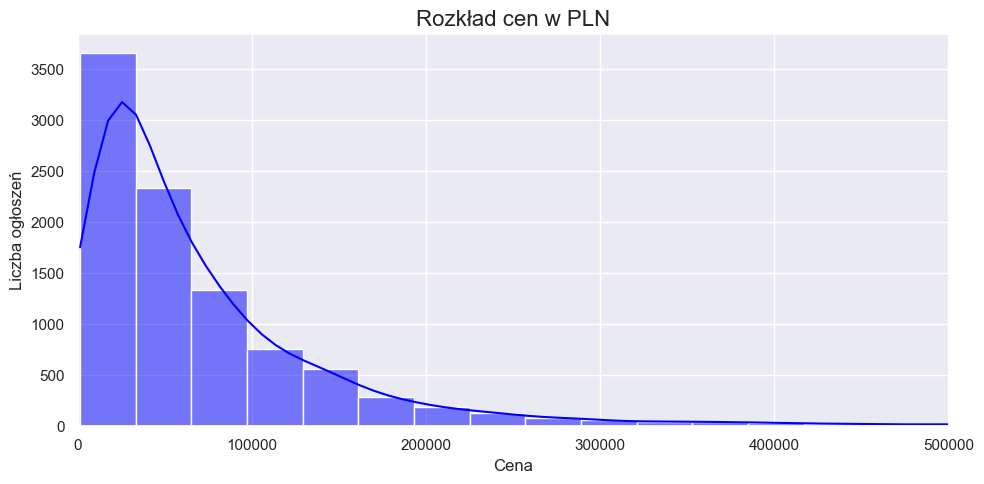

In [72]:
#Rozkład cen
plt.figure(figsize=(10, 5))
sns.histplot(data['Cena'], bins=50, kde=True, color='blue')
plt.title('Rozkład cen w PLN', fontsize=16)
plt.xlabel('Cena', fontsize=12)
plt.ylabel('Liczba ogłoszeń', fontsize=12)
plt.xlim(0, 500000)
plt.tight_layout()
plt.show()

Najważniejsze wnioski:
1. Większość ofert oscyluje w średnich lub dolnych przedziałach cenowych, głównie poniżej 100 tys. złotych
2. Silny układ skośny może nieść za sobą konieczność zastosowania transformacji logarytmicznej zmiennej objasniającej ze względu na potencjalny wpływ najdroższych ofert na dopasowanie modelu regresji
3. Oferty luksusowych samochodów w próbie stanowią znaczną mniejszość

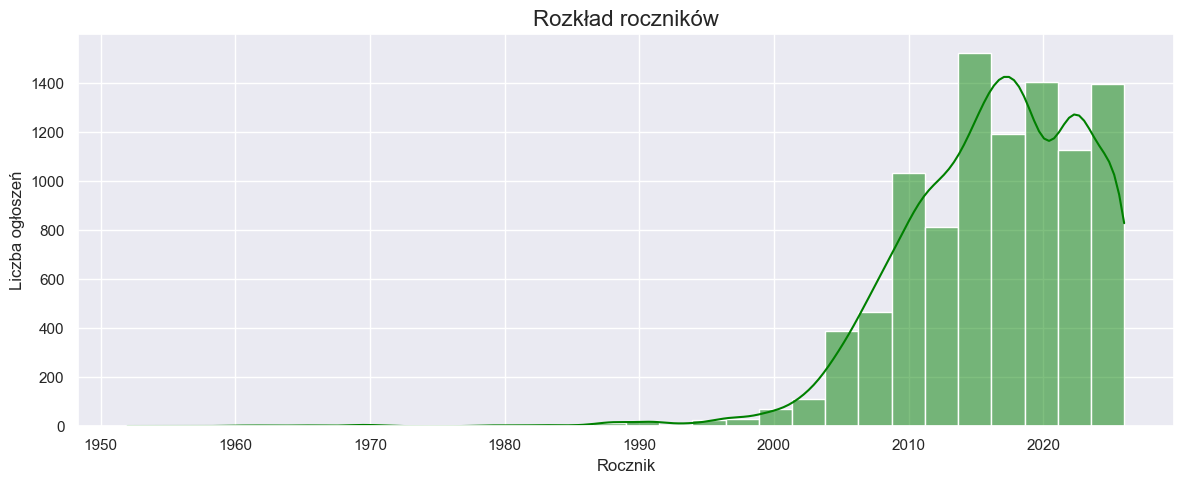

In [75]:
#Rozkład roczników
plt.figure(figsize=(12, 5))
sns.histplot(data['Rocznik'], bins=30, kde=True, color='green')
plt.title('Rozkład roczników', fontsize=16)
plt.xlabel('Rocznik', fontsize=12)
plt.ylabel('Liczba ogłoszeń', fontsize=12)
plt.tight_layout()
plt.show()

Najważniejsze wnioski:
1. Większość ofert dotyczy samochodów wyprodukowanych po 2010 roku
2. Stare samochody (sprzed 2000) roku stanowią margines, może to mieć związek z ustawą klimatyczną w Krakowie dotyczącą użytkowania samochodów sprzed 2004 roku
3. Dynamiczny wzrost od 2005 roku
4. Wahania ostatnich latach mogą odzwierciedlać trendy rynkowe, problemy z dostępnością nowych samochodów w salonach lub inną specyfikę rotacji ogłoszeń

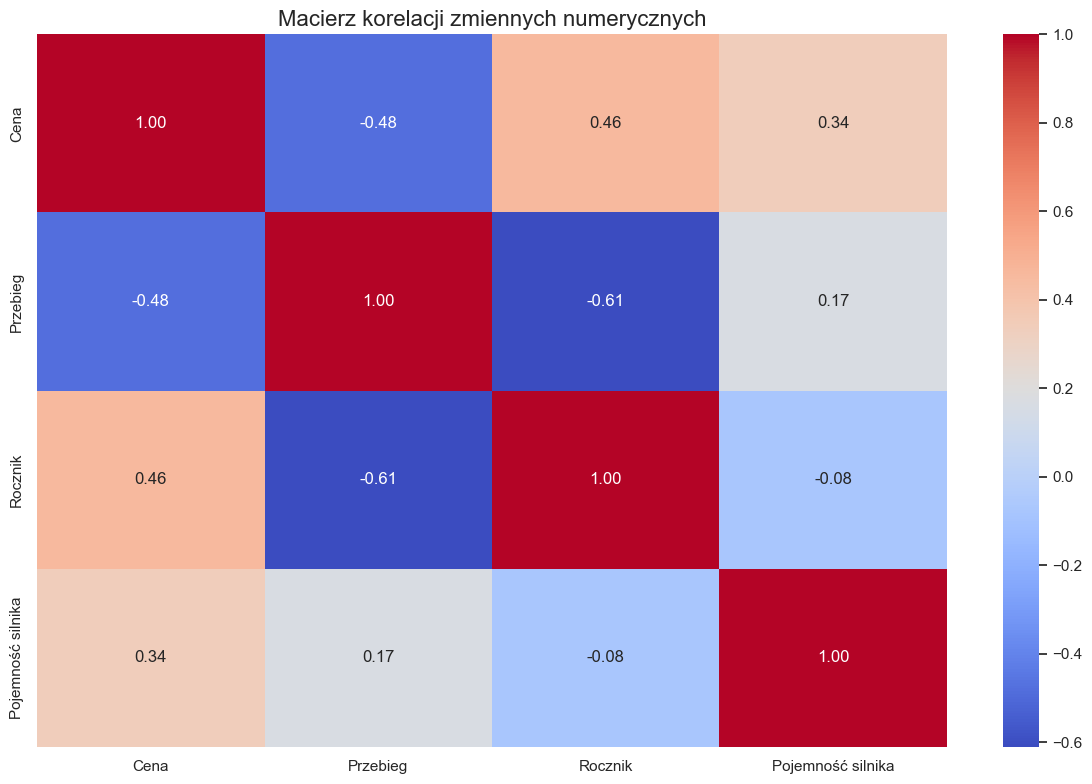

In [76]:
#Macierz korelacji numerycznych zmiennych
plt.figure(figsize=(12, 8))
numeric_cols = data.select_dtypes(include=[np.number]).columns
correlation_matrix = data[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Macierz korelacji zmiennych numerycznych', fontsize=16)
plt.tight_layout()
plt.show()


Najważniejsze wnioski:
1. Występuje umiarkowana korelacja ujemna między ceną a przebiegiem.
2. Występuje umiarkowana korelacja dodatnia między ceną a rocznikiem
3. Występuje słaba/umiarkowana korelacja dodatnia między ceną a pojemnością silnika
4. Występuje dosyć silna korelacja ujemna między przebiegiem a rocznikiem


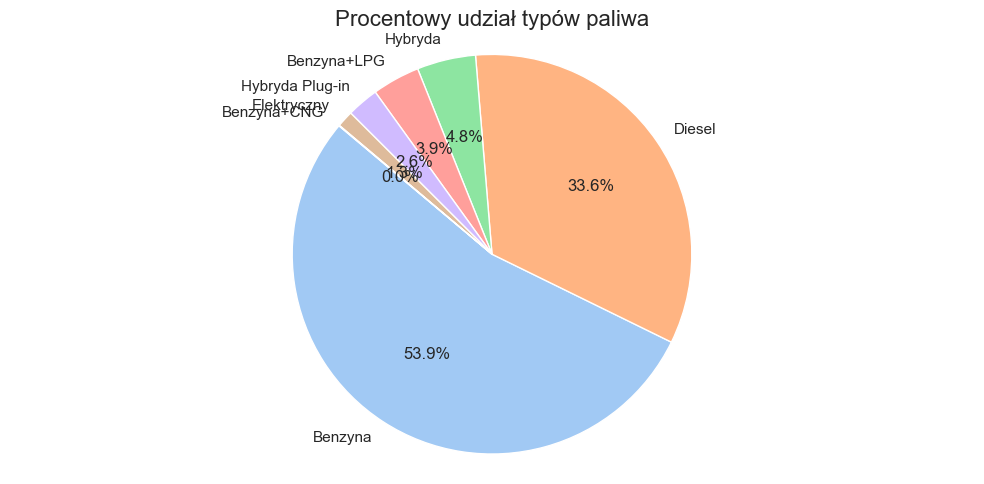

In [77]:
#Wykres kołowy dla typu paliwa
plt.figure(figsize=(10, 5))
fuel_counts = data['Paliwo'].value_counts()
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Procentowy udział typów paliwa', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

Najważniejsze wnioski:
1. Ponad połowę ogłoszeń stanowią samochody o napędzie benzyna
2. Diesiel stanowi 1/3 ofert
3. 3 miejse stanowi Hrybryda niemal na równi z Benzyna +LPG
4. Bardzo niski udział samochodów elektrycznych, Benzyna + CNG oraz Hybrydy Plug-in na rynku wtórym w Krakowie

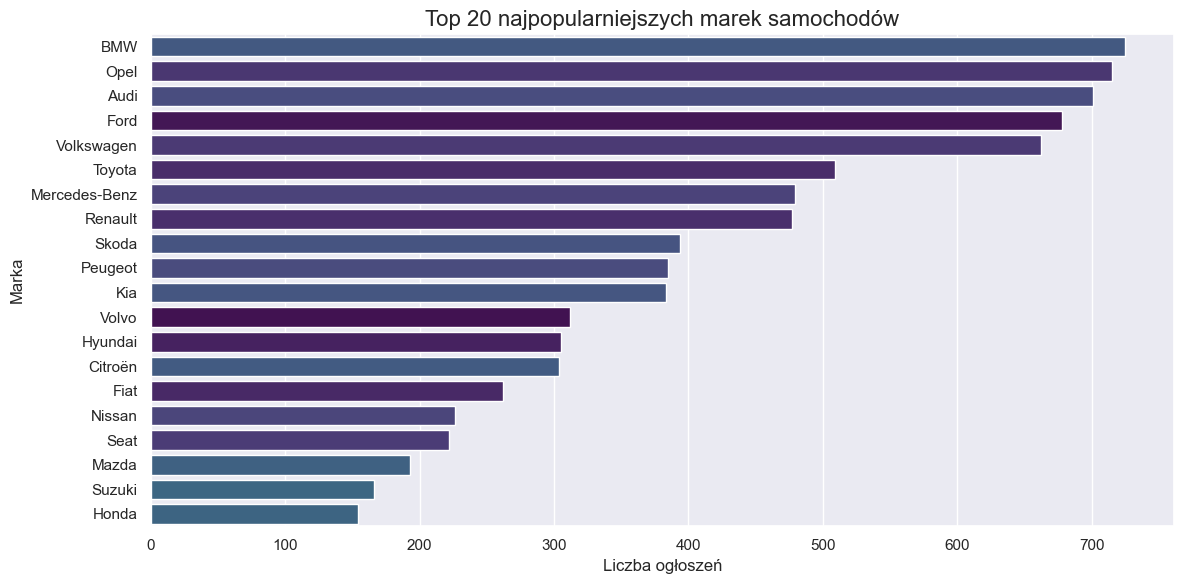

In [81]:
#Histogram przedstawiający rozkład Marek samochodów
top_20_marek = data['Marka'].value_counts().head(20).index

plt.figure(figsize=(12, 6))
sns.countplot(
    y='Marka', 
    data=data, 
    order=top_20_marek, 
    palette='viridis', 
    hue='Marka', 
    legend=False
)
plt.title('Top 20 najpopularniejszych marek samochodów', fontsize=16)
plt.xlabel('Liczba ogłoszeń', fontsize=12)
plt.ylabel('Marka', fontsize=12)
plt.tight_layout()
plt.show()